# Reparameterization of Hierarchical Models in HSSM

*Authors: Maria Ma, Andrew Zhang*

## 1. Introduction

This tutorial walks you through the **centered** and **non-centered** parameterizations of a hierarchical model in HSSM — two mathematically equivalent forms that the sampler can treat very differently (one mixes cleanly, the other fills the trace with divergences and poor mixing).

We use one hierarchical HSSM model — drift rate `v` varying across subjects — and:

- fit it under both parameterizations,
- vary the data per subject (5 / 30 / 100 / 500 / 1000 trials) to see which form wins,
- read simple diagnostics (R-hat, ESS, divergences, and a few plots),
- push the ground-truth `sigma_v` and the number of subjects until the sampler visibly breaks (§7).

**Key result:** few trials per subject favor the non-centered form; many trials favor the centered form. In HSSM you switch between them with one argument, `noncentered=True/False`.

## 2. Background

### 2.1 Centered parameterization

The standard formulation of a hierarchical model: each subject's drift `v_k` is drawn around a group mean.

- group mean `mu_v`, group spread `sigma_v`
- each subject: `v_k ~ Normal(mu_v, sigma_v)`

Here `sigma_v` acts as a *freedom parameter*: a large value lets subjects differ; a small value pulls every subject toward the group mean. Because the spread of the `v_k` is governed directly by `sigma_v`, the two are tightly coupled, which causes funnel degeneracy.

### 2.2 Non-centered parameterization

The same model, rewritten so that the group spread and the subject values are no longer directly coupled. Each subject is assigned a standardized offset, and `v_k` is reconstructed from it:

- offset: `z_k ~ Normal(0, 1)`
- each subject: `v_k = mu_v + sigma_v * z_k`

Because the offsets no longer depend on `sigma_v`, the geometry the sampler explores is well-behaved. 


### 2.3 The funnel degeneracy

The **funnel degeneracy** appears when two things coincide: **`sigma_v` is small** and **per-subject data is weak**.

With little data, the likelihood barely constrains a subject's `v_k`, so the prior takes over and `sigma_v` controls how freely the subjects move. If `sigma_v` is also small, the subjects are all pulled tight to the group mean. Geometrically, the joint density is wide at large `sigma_v` and pinches into a thin **neck** at small `sigma_v` — Neal's funnel (**left panel**). A step size that works well in the wide region is too aggressive in the narrow neck, so the sampler either moves inefficiently (low ESS) or loses track of the geometry altogether (divergences).

With abundant per-subject data the likelihood pins each `v_k` on its own, so `v_k` no longer moves with `sigma_v` and the joint geometry is a round, well-behaved blob (**right panel**; note the much narrower x-axis). 

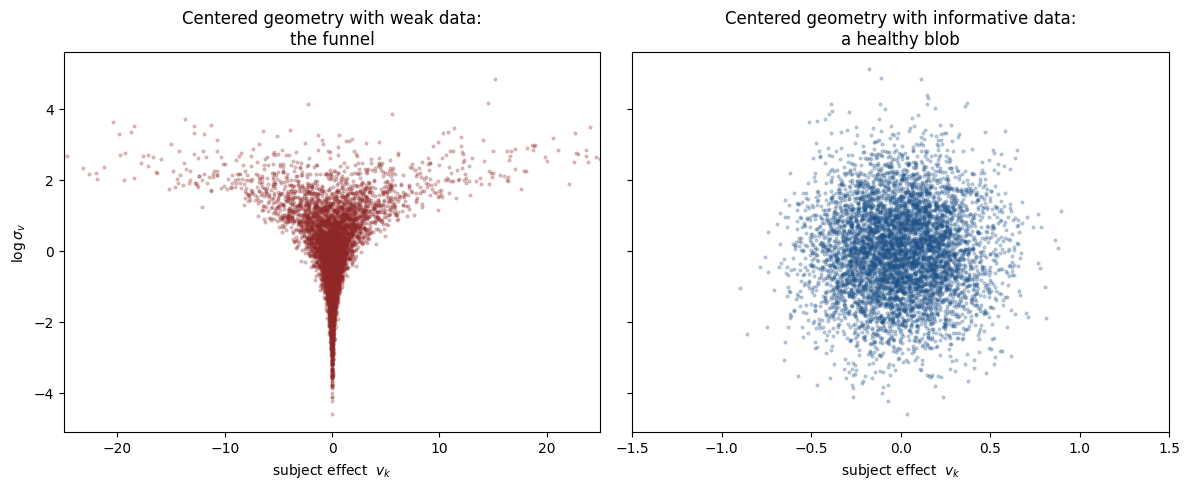

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

n = 6000

log_sigma = rng.normal(0.0, 1.3, n)
v_weak = rng.normal(0.0, np.exp(log_sigma))
v_strong = rng.normal(0.0, 0.25, n)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].scatter(v_weak, log_sigma, s=4, alpha=0.25, color="#8F2727")
axes[0].set_xlim(-25, 25)
axes[0].set_title("Centered geometry with weak data:\nthe funnel")
axes[1].scatter(v_strong, log_sigma, s=4, alpha=0.25, color="#1E5288")
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_title("Centered geometry with informative data:\na healthy blob")
for ax in axes:
    ax.set_xlabel(r"subject effect  $v_k$")
axes[0].set_ylabel(r"$\log \sigma_v$")
plt.tight_layout()
plt.show()

### 2.4 Non-centering: undoing a funnel degeneracy, or creating one

Non-centering is not always a fix — its effect depends on whether a funnel degeneracy is already present.

When the centered form has a funnel (little data), non-centering resolves it: the offsets `z_k ~ Normal(0, 1)` no longer depend on `sigma_v`, so the joint geometry is a round, well-behaved blob (**left panel**).

When there is no funnel to begin with (abundant data), non-centering can instead *create* one. The data pin each `v_k` near a fixed value — up to a small residual spread — so the offset `z_k = (v_k - mu_v) / sigma_v` must scale like `1 / sigma_v`: the offsets blow up as `sigma_v` shrinks, fanning out into the **inverse funnel degeneracy** (**right panel**; note the wider x-axis).

The two forms therefore fail in opposite regimes: centered with *little* data, non-centered with *abundant* data.

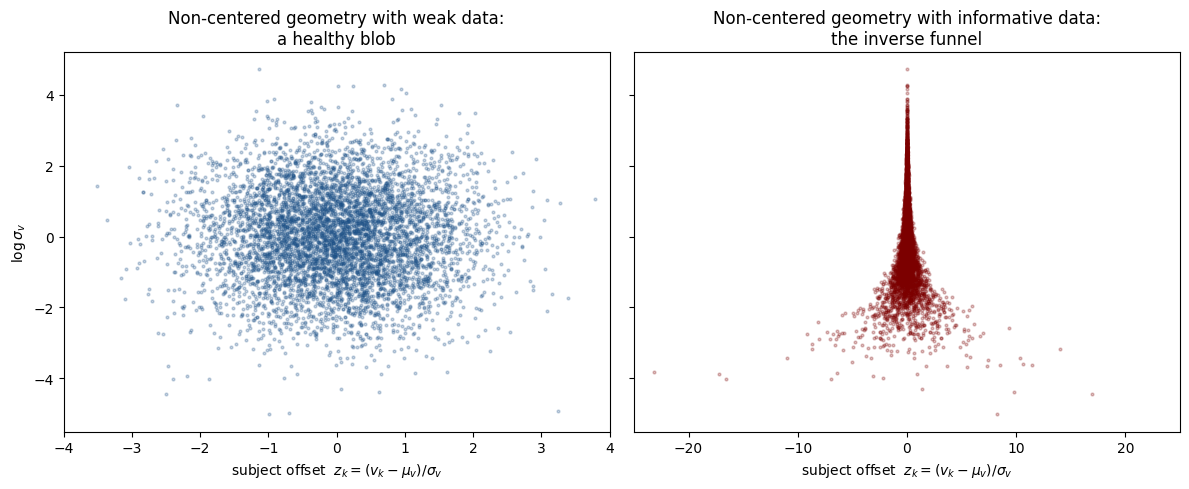

In [28]:
mu_v = 0.0

log_sigma = rng.normal(0.0, 1.3, n)
sigma = np.exp(log_sigma)

offset_weak = rng.normal(0.0, 1.0, n)
z_k = rng.normal(mu_v, 0.25, n)
offset_strong = (z_k - mu_v) / sigma

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].scatter(offset_weak, log_sigma, s=4, alpha=0.25, color="#1E5288")
axes[0].set_xlim(-4, 4)
axes[0].set_title("Non-centered geometry with weak data:\na healthy blob")
axes[1].scatter(offset_strong, log_sigma, s=4, alpha=0.25, color="#7C0000")
axes[1].set_xlim(-25, 25)
axes[1].set_title("Non-centered geometry with informative data:\nthe inverse funnel")
for ax in axes:
    ax.set_xlabel(r"subject offset  $z_k = (v_k-\mu_v)/\sigma_v$")
axes[0].set_ylabel(r"$\log \sigma_v$")
plt.tight_layout()
plt.show()

## 3. Simulation Setup

We build a hierarchical HSSM model where only the drift rate `v` varies across subjects (`a`, `z`, `t` are shared) and simulate every dataset up front, each defined by a `(n_trials, sigma_v, n_subjects)` setting: the main sweep — **5 / 30 / 100 / 500 / 1000** trials/subject at `sigma_v = 0.1` (§4–6) — plus the `sigma_v` and subjects sweeps for §7. Sparse data favors non-centered; rich data favors centered; intermediate settings trace the crossover.

Each dataset is generated with the **do-operator** (`model.sample_do`), which fixes every parameter to a known value before drawing fresh `rt`/`response` — so we know exactly what produced each fit and can check recovery later. The standardized offsets `z_k ~ Normal(0, 1)` are drawn once and shared, so every setting sees "the same" subjects.

In [3]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import hssm

seed = np.random.default_rng(2026)

sample_kwargs = dict(
    sampler="pymc",
    draws=1000,
    tune=1000,
    chains=4,
    cores=1,
    target_accept=0.9,
    progressbar=False,
    idata_kwargs={"log_likelihood": False},
)

In [4]:
mu_v = 1.0
sigma_v = 0.1
a_true = 1.5
z_true = 0.5
t_true = 0.3

n_subjects = 20

trials_settings = [5, 30, 100, 500, 1000]
sigma_v_settings = [0.3, 0.1, 0.05, 0.02]
n_subjects_settings = [10, 20, 40]

v_offsets_all = seed.normal(0.0, 1.0, max(n_subjects_settings))

v_offsets = v_offsets_all[:n_subjects]
v_subjects = mu_v + sigma_v * v_offsets

In [5]:
v_formula = "v ~ 1 + (1|participant_id)"


def make_covariates(n_trials, n_subj):
    """Long-format covariate table: n_subj subjects with n_trials rows each."""
    pid = np.repeat(np.arange(n_subj), n_trials)
    return pd.DataFrame({"participant_id": pid})

In [6]:
gen_settings = [(n, sigma_v, n_subjects) for n in trials_settings]
gen_settings += [
    (trials_settings[0], s, n_subjects) for s in sigma_v_settings if s != sigma_v
]
gen_settings += [(500, 0.05, n_subjects)]
gen_settings += [
    (trials_settings[0], sigma_v, ns) for ns in n_subjects_settings if ns != n_subjects
]

datasets = {}
for n_trials, sigma_v_true, n_subj in gen_settings:
    covariates = make_covariates(n_trials, n_subj)

    do_params = {
        "v_Intercept": mu_v,
        "v_1|participant_id_sigma": sigma_v_true,
        "v_1|participant_id_offset": v_offsets_all[:n_subj],
        "a": a_true,
        "z": z_true,
        "t": t_true,
    }

    gen_model = hssm.HSSM(
        data=covariates.assign(rt=1.0, response=1.0),
        model="ddm",
        include=[{"name": "v", "formula": v_formula}],
        noncentered=True,
        prior_settings=None,
    )
    synth_idata, _ = gen_model.sample_do(
        params=do_params,
        draws=1,
        var_names=["rt,response"],
        return_model=True,
    )
    synth_df = hssm.utils.predictive_idata_to_dataframe(
        synth_idata, predictive_group="prior_predictive"
    )

    df = covariates.copy()
    df["rt"] = synth_df["rt"].values
    df["response"] = synth_df["response"].values
    datasets[(n_trials, sigma_v_true, n_subj)] = df
    df.to_csv(f"sim_repar_t{n_trials}_s{sigma_v_true}_n{n_subj}.csv", index=False)

/Users/mayan/HSSM/src/hssm/base.py:346: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()


Model initialized successfully.


Sampling: [rt,response]


Model initialized successfully.


/Users/mayan/HSSM/src/hssm/base.py:346: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()


...

Sampling: [rt,response]


Model initialized successfully.


/Users/mayan/HSSM/src/hssm/base.py:346: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()
Sampling: [rt,response]


Model initialized successfully.


/Users/mayan/HSSM/src/hssm/base.py:346: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()
Sampling: [rt,response]


## 4. Fit Both Models Across the Main Sweep

For each main-sweep dataset from §3, we fit the model twice — once centered, once non-centered — for ten fits total. The data and model are identical in both runs, so any difference in the diagnostics comes from the sampling geometry alone.

We record R-hat, bulk-ESS, and divergence count for `sigma_v` (the parameter most affected by the funnel).

In [7]:
parameterizations = [("centered", False), ("non-centered", True)]
sigma_v_var = "v_1|participant_id_sigma"


def fit_both(data, **setting):
    recs, idatas = [], {}
    for label, nc in parameterizations:
        model = hssm.HSSM(
            data=data,
            model="ddm",
            include=[{"name": "v", "formula": v_formula}],
            noncentered=nc,
            prior_settings=None,
        )
        idata = model.sample(**sample_kwargs)
        idatas[label] = idata

        summ = az.summary(idata, var_names=[sigma_v_var])
        rec = {
            **setting,
            "parameterization": label,
            "divergences": int(idata.sample_stats["diverging"].sum()),
            "rhat_sigma_v": float(summ["r_hat"].iloc[0]),
            "ess_sigma_v": float(summ["ess_bulk"].iloc[0]),
        }
        recs.append(rec)
        desc = ", ".join(f"{k}={v}" for k, v in setting.items())
        print(
            f"{desc} | {label:>12}: div={rec['divergences']}, "
            f"rhat={rec['rhat_sigma_v']:.3f}, ess={rec['ess_sigma_v']:.0f}"
        )
    return recs, idatas


idata_store = {}
records = []
for n_trials in trials_settings:
    data = datasets[(n_trials, sigma_v, n_subjects)]
    recs, idatas = fit_both(data, n_trials=n_trials)
    records.extend(recs)
    for label, idata in idatas.items():
        idata_store[(n_trials, label)] = idata

Model initialized successfully.


Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [a, z, t, v_Intercept, v_1|participant_id_sigma, v_1|participant_id]


...


 99%|█████████▉| 3961/4000 [00:27<00:00, 139.99it/s]


 99%|█████████▉| 3976/4000 [00:27<00:00, 140.31it/s]


100%|█████████▉| 3991/4000 [00:27<00:00, 139.90it/s]


100%|██████████| 4000/4000 [00:28<00:00, 142.64it/s]

n_trials=1000 | non-centered: div=0, rhat=1.010, ess=1101


## 5. Results Summary Table


In [8]:
results = pd.DataFrame.from_records(records)

summary_table = results.pivot(
    index="n_trials",
    columns="parameterization",
    values=["divergences", "rhat_sigma_v", "ess_sigma_v"],
)
summary_table = summary_table.reindex(
    columns=pd.MultiIndex.from_product(
        [["divergences", "rhat_sigma_v", "ess_sigma_v"], ["centered", "non-centered"]]
    )
)
summary_table.round(3)

divergences              rhat_sigma_v              ess_sigma_v  \
            centered non-centered     centered non-centered    centered   
n_trials                                                                  
5                1.0          0.0         1.05         1.00       111.0   
30               1.0          0.0         1.04         1.00        92.0   
100              0.0          0.0         1.01         1.00       296.0   
500              0.0          0.0         1.00         1.00      2575.0   
1000             0.0          0.0         1.00         1.01      3920.0   

                       
         non-centered  
n_trials               
5              1208.0  
30             1775.0  
100             973.0  
500            1593.0  
1000           1101.0

At 5 and 30 trials per subject the centered form is visibly broken: divergences appear, R-hat fails (1.04–1.05), and its ESS for `σ_v` collapses to ~100 while non-centered delivers 1200–1800. Between 100 and 500 trials the ranking flips; by 1000 trials centered has ~3.5× the ESS of non-centered, and the R-hat flag has moved to the non-centered side. This regime change is exactly the prediction of §2: centered struggles when data are scarce; non-centered struggles when data are abundant.

## 6. Diagnostics Deep Dive

We examine the two extreme settings — **5 trials** (non-centered wins) and **1000 trials** (centered wins) — along three axes: the posterior geometry (§6.1), chain mixing (§6.2), and parameter recovery (§6.3).

### 6.1 Pair plots: the funnel geometry

For each (n_trials, parameterization) we plot `log σ_v` against subject 0's random effect (offset, for non-centered). The dashed line marks the true `log σ_v ≈ -2.30`. One healthy and one defective geometry appears per parameterization.

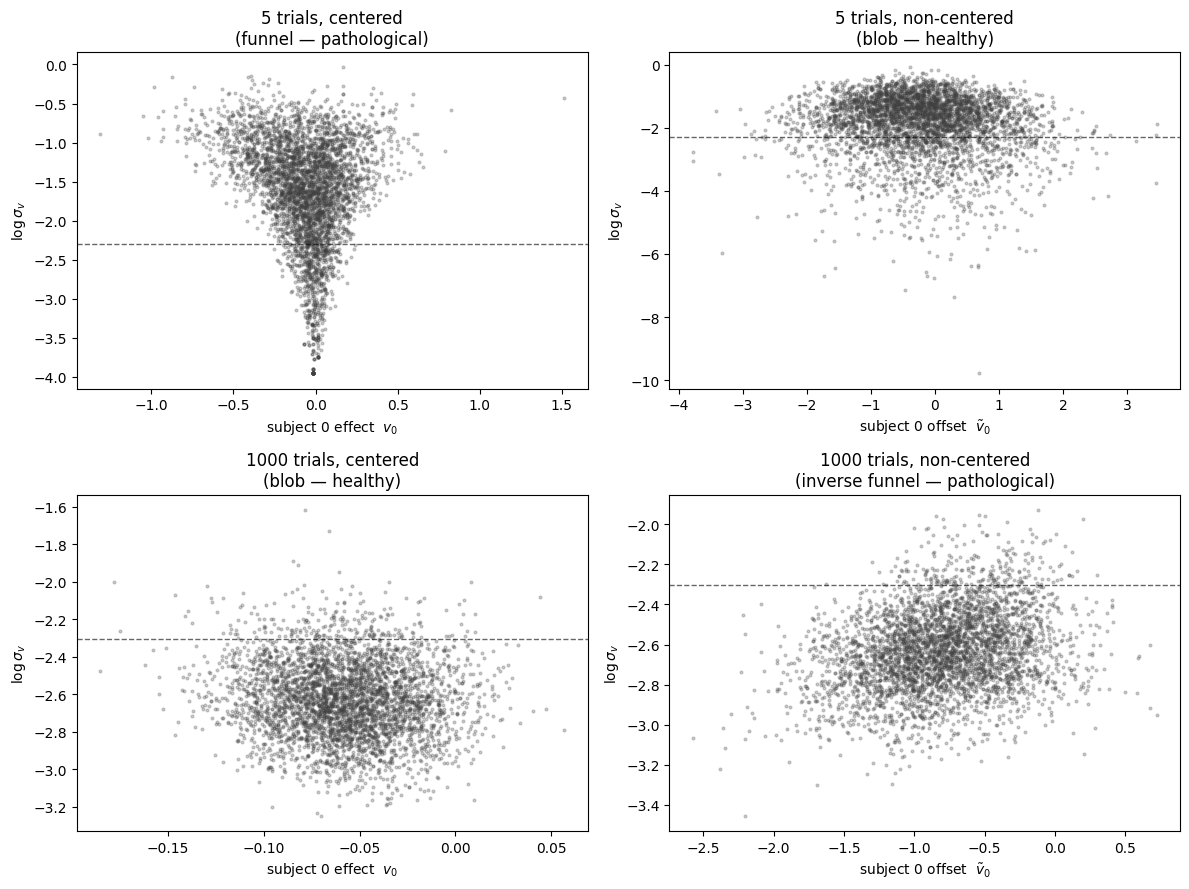

In [9]:
sparse, rich = trials_settings[0], trials_settings[-1]
contrasts = [
    (sparse, "centered"),
    (sparse, "non-centered"),
    (rich, "centered"),
    (rich, "non-centered"),
]
verdicts = {
    (sparse, "centered"): "funnel — pathological",
    (sparse, "non-centered"): "blob — healthy",
    (rich, "centered"): "blob — healthy",
    (rich, "non-centered"): "inverse funnel — pathological",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (n_trials, label) in zip(axes.flat, contrasts):
    idata = idata_store[(n_trials, label)]

    sigma = idata.posterior[sigma_v_var].values.flatten()
    log_sigma = np.log(sigma)

    re_name = (
        "v_1|participant_id_offset" if label == "non-centered" else "v_1|participant_id"
    )
    subj_effect = idata.posterior[re_name].values[..., 0].flatten()

    ax.scatter(subj_effect, log_sigma, s=4, alpha=0.25, color="#404040")
    ax.axhline(np.log(sigma_v), color="k", ls="--", lw=1, alpha=0.6)

    xlabel = (
        r"subject 0 offset  $\tilde v_0$"
        if label == "non-centered"
        else r"subject 0 effect  $v_0$"
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$\log \sigma_v$")
    ax.set_title(f"{n_trials} trials, {label}\n({verdicts[(n_trials, label)]})")
plt.tight_layout()
plt.show()

The funnel (top-left) and the milder inverse funnel (bottom-right) sit opposite two healthy blobs.

### 6.2 Trace plots of `σ_v`

Each chain's `σ_v` across 1000 draws; the dashed line marks the true `σ_v = 0.1`.

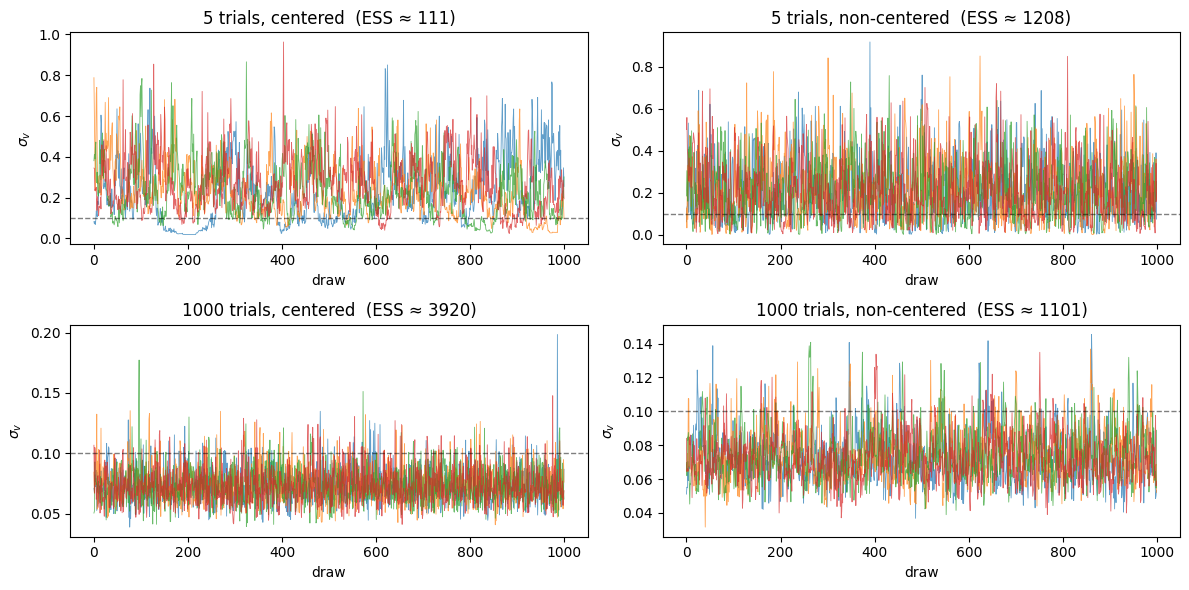

In [10]:
ess_map = {
    (r.n_trials, r.parameterization): r.ess_sigma_v for r in results.itertuples()
}

contrasts = [
    (sparse, "centered"),
    (sparse, "non-centered"),
    (rich, "centered"),
    (rich, "non-centered"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, (n_trials, label) in zip(axes.flat, contrasts):
    idata = idata_store[(n_trials, label)]
    samples = idata.posterior[sigma_v_var].values
    for c in range(samples.shape[0]):
        ax.plot(samples[c], alpha=0.7, lw=0.6)
    ax.axhline(sigma_v, color="k", ls="--", lw=1, alpha=0.5)
    ax.set_title(
        f"{n_trials} trials, {label}  (ESS ≈ {ess_map[(n_trials, label)]:.0f})"
    )
    ax.set_xlabel("draw")
    ax.set_ylabel(r"$\sigma_v$")
plt.tight_layout()
plt.show()

At 5 trials the centered chains are sticky, pinned near small `σ_v` for hundreds of draws (the funnel's neck), while the non-centered chains mix freely. At 1000 trials the roles reverse more mildly: centered forms a tight band, non-centered mixes ~3.5× less efficiently.

### 6.3 Recovery of `σ_v`

Posterior mean ± sd for both forms. Dashed line: true `σ_v = 0.1`; dotted line: the empirical spread of the 20 simulated subjects (≈ 0.074).

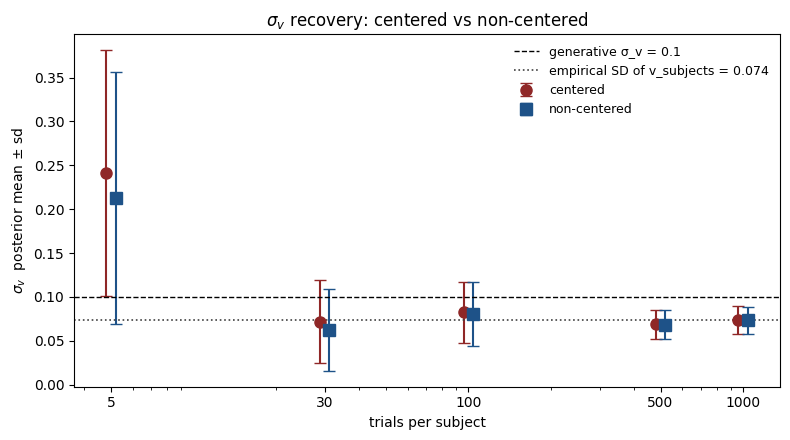

,n_trials,parameterization,post_mean,post_sd
0,5,centered,0.241,0.140
1,5,non-centered,0.213,0.144
2,30,centered,0.072,0.048
3,30,non-centered,0.063,0.047
4,100,centered,0.083,0.035
5,100,non-centered,0.081,0.036
6,500,centered,0.069,0.017
7,500,non-centered,0.068,0.017
8,1000,centered,0.074,0.015
9,1000,non-centered,0.074,0.015


In [11]:
rec_sigma = []
for n_trials in trials_settings:
    for label in ["centered", "non-centered"]:
        idata = idata_store[(n_trials, label)]
        post = idata.posterior[sigma_v_var].values.flatten()
        rec_sigma.append(
            {
                "n_trials": n_trials,
                "parameterization": label,
                "post_mean": float(np.mean(post)),
                "post_sd": float(np.std(post)),
            }
        )
sigma_recovery = pd.DataFrame(rec_sigma)

empirical_sd = float(np.std(v_subjects, ddof=1))

fig, ax = plt.subplots(figsize=(8, 4.5))
for label, color, marker, off in [
    ("centered", "#8F2727", "o", -0.04),
    ("non-centered", "#1E5288", "s", 0.04),
]:
    sub = sigma_recovery[sigma_recovery.parameterization == label]
    x = sub.n_trials * (1 + off)
    ax.errorbar(
        x,
        sub.post_mean,
        yerr=sub.post_sd,
        fmt=marker,
        color=color,
        label=label,
        capsize=4,
        ms=8,
    )
ax.axhline(sigma_v, color="k", ls="--", lw=1, label=f"generative σ_v = {sigma_v}")
ax.axhline(
    empirical_sd,
    color="#404040",
    ls=":",
    lw=1.2,
    label=f"empirical SD of v_subjects = {empirical_sd:.3f}",
)
ax.set_xscale("log")
ax.set_xticks(trials_settings)
ax.set_xticklabels(trials_settings)
ax.set_xlabel("trials per subject")
ax.set_ylabel(r"$\sigma_v$  posterior mean ± sd")
ax.set_title(r"$\sigma_v$ recovery: centered vs non-centered")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
sigma_recovery.round(3)

From 30 trials onward the two forms give the same answer—choosing centered vs non-centered changes how fast the sampler mixes (the ESS gap in §5), not the estimate itself. Both converge on the empirical SD 0.074 rather than the generative 0.1, because we only drew 20 subjects and their actual spread differs from the value they were sampled from. At 5 trials the data is too thin to pin down σ_v, so the prior pulls both estimates up; centered is pulled slightly more, because the funnel makes the small-σ_v region harder to visit.

## 7. More exploration

### 7.1 Changing the true `σ_v`

Holding the sparse setting (5 trials, 20 subjects), we shrink `σ_v` from 0.3 to 0.02 to test how small the true spread must be before the centered form fails.

In [12]:
sigma_records = []
for s in sigma_v_settings:
    recs, _ = fit_both(datasets[(sparse, s, n_subjects)], sigma_v_true=s)
    sigma_records.extend(recs)

sigma_sweep_table = pd.DataFrame(sigma_records).pivot(
    index="sigma_v_true",
    columns="parameterization",
    values=["divergences", "rhat_sigma_v", "ess_sigma_v"],
)
sigma_sweep_table.round(3)

Model initialized successfully.


Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [a, z, t, v_Intercept, v_1|participant_id_sigma, v_1|participant_id]


...


  0%|          | 0/4000 [00:00<?, ?it/s]


 55%|█████▌    | 2215/4000 [00:00<00:00, 22141.36it/s]


100%|██████████| 4000/4000 [00:00<00:00, 21928.51it/s]

sigma_v_true=0.02 | non-centered: div=0, rhat=1.000, ess=807


divergences              rhat_sigma_v               \
parameterization    centered non-centered     centered non-centered   
sigma_v_true                                                          
0.02                     0.0          0.0         1.06         1.00   
0.05                     0.0          0.0         1.08         1.00   
0.10                    75.0          0.0         1.54         1.00   
0.30                     1.0          0.0         1.04         1.01   

                 ess_sigma_v               
parameterization    centered non-centered  
sigma_v_true                               
0.02                    66.0        807.0  
0.05                    36.0       1595.0  
0.10                     7.0       1223.0  
0.30                    95.0        832.0

The centered form fails across the sweep — ESS never exceeds ~100 and R-hat fails throughout, collapsing entirely at `σ_v = 0.1` (75 divergences, R-hat 1.54, ESS 7). The non-centered form is unaffected.

The mirror case — small `σ_v` with rich data — should instead affect the non-centered form (§2.4). One probe at 500 trials, `σ_v = 0.05`:

In [13]:
rich_records, _ = fit_both(
    datasets[(500, 0.05, n_subjects)], n_trials=500, sigma_v_true=0.05
)
pd.DataFrame(rich_records).round(3)

Model initialized successfully.


Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [a, z, t, v_Intercept, v_1|participant_id_sigma, v_1|participant_id]


...


 98%|█████████▊| 3937/4000 [00:14<00:00, 311.61it/s]


 99%|█████████▉| 3970/4000 [00:14<00:00, 315.48it/s]


100%|██████████| 4000/4000 [00:14<00:00, 277.04it/s]

n_trials=500, sigma_v_true=0.05 | non-centered: div=0, rhat=1.000, ess=788


,n_trials,sigma_v_true,parameterization,divergences,rhat_sigma_v,ess_sigma_v
0,500,0.05,centered,0,1.01,366.0
1,500,0.05,non-centered,0,1.00,788.0


The non-centered form again holds (ESS 788 vs 366, both clean). In this model rich data degrades non-centered sampling gradually rather than breaking it.

### 7.2 Varying the number of subjects

We vary the group size at the setting 5 trials, `σ_v = 0.1` to determine which effect dominates.

In [14]:
subj_records = []
for ns in n_subjects_settings:
    recs, _ = fit_both(datasets[(sparse, sigma_v, ns)], n_subjects=ns)
    subj_records.extend(recs)

subj_table = pd.DataFrame(subj_records).pivot(
    index="n_subjects",
    columns="parameterization",
    values=["divergences", "rhat_sigma_v", "ess_sigma_v"],
)
subj_table.round(3)

Model initialized successfully.


Using default initvals. 



Initializing NUTS using adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [a, z, t, v_Intercept, v_1|participant_id_sigma, v_1|participant_id]


...


 36%|███▌      | 1421/4000 [00:00<00:00, 14207.03it/s]


 71%|███████   | 2842/4000 [00:00<00:00, 14140.06it/s]


100%|██████████| 4000/4000 [00:00<00:00, 14020.57it/s]

n_subjects=40 | non-centered: div=0, rhat=1.000, ess=652


divergences              rhat_sigma_v               \
parameterization    centered non-centered     centered non-centered   
n_subjects                                                            
10                       7.0          0.0         1.03          1.0   
20                       0.0          0.0         1.04          1.0   
40                     561.0          0.0         1.58          1.0   

                 ess_sigma_v               
parameterization    centered non-centered  
n_subjects                                 
10                     117.0       1052.0  
20                     112.0       1469.0  
40                       7.0        652.0

Additional subjects worsen the centered form: at 40 subjects it collapses (561 divergences, R-hat 1.58, ESS 7). With only 5 trials each, extra subjects add no information about the individual `v_k` — the posterior geometry becomes increasingly concentrated in the narrow-neck region associated with small `σ_v`, making HMC exploration harder. 

The non-centered form remains clean at every group size.
